# 1. Carregamento de Dados 

In [ ]:
import pandas as pd

# carregar dados da camada Gold
credenciais_minio = {
    "key": "minio",
    "secret": "minio123",
    "client_kwargs": {
        "endpoint_url": "http://localhost:9000"
    }
}
df = pd.read_parquet('s3://gold/gold_data.parquet',storage_options=credenciais_minio)

print("Quantidade de registros:", len(df))
df.head()

Quantidade de registros: 34987


,business_id,name,city,categories,categories_list,price_range,has_delivery,has_outdoor,stars,review_count,gold_score,rag_context,embedding_list
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,Philadelphia,Restaurants Food Bubble Tea Coffee & Tea B...,[Restaurants Food Bubble Tea Coffee & Tea ...,1,False,False,4.0,80,0.634356,Nome: St Honore Pastries. Local: Philadelphia....,"[0.0035318147856742144, -0.008946051821112633,..."
1,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,Ashland City,Burgers Fast Food Sandwiches Food Ice Crea...,[Burgers Fast Food Sandwiches Food Ice Cre...,1,True,True,2.0,6,0.181477,Nome: Sonic Drive-In. Local: Ashland City. Est...,"[-0.005798297934234142, 0.013337074778974056, ..."
2,bBDDEgkFA1Otx9Lfe7BZUQ,Sonic Drive-In,Nashville,Ice Cream & Frozen Yogurt Fast Food Burgers ...,[Ice Cream & Frozen Yogurt Fast Food Burgers...,1,True,True,1.5,10,0.112968,Nome: Sonic Drive-In. Local: Nashville. Estilo...,"[0.01703026331961155, 0.0003804313892032951, 0..."
3,eEOYSgkmpB90uNA7lDOMRA,Vietnamese Food Truck,Tampa Bay,Vietnamese Food Restaurants Food Trucks,[Vietnamese Food Restaurants Food Trucks],1,False,False,4.0,10,0.550468,Nome: Vietnamese Food Truck. Local: Tampa Bay....,"[0.01165863499045372, 0.007707028184086084, -0..."
4,il_Ro8jwPlHresjw9EGmBg,Denny's,Indianapolis,American (Traditional) Restaurants Diners B...,[American (Traditional) Restaurants Diners ...,1,True,False,2.5,28,0.328698,Nome: Denny's. Local: Indianapolis. Estilo: Am...,"[0.03403853625059128, -0.01017673872411251, 0...."


# 2. Ánalise Exploratoria (EDA)

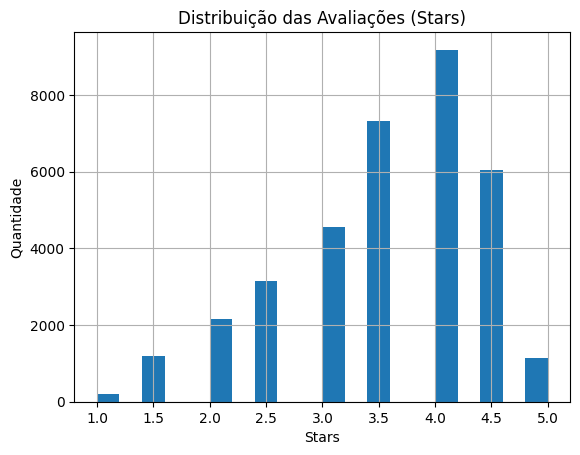

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribuição das estrelas
plt.figure()
df['stars'].hist(bins=20)
plt.title("Distribuição das Avaliações (Stars)")
plt.xlabel("Stars")
plt.ylabel("Quantidade")
plt.show()

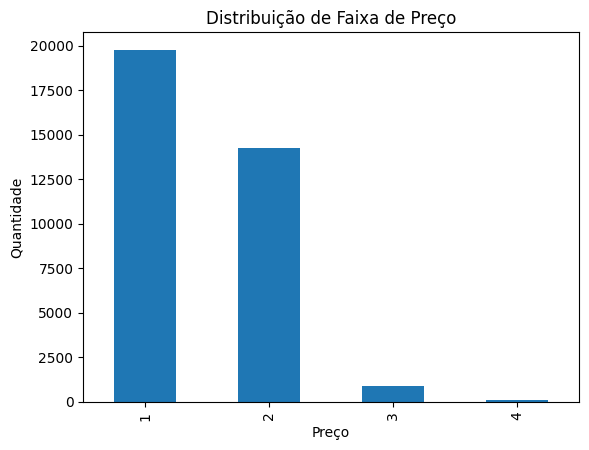

In [ ]:
# Distribuição de preços
plt.figure()
df['price_range'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribuição de Faixa de Preço")
plt.xlabel("Preço")
plt.ylabel("Quantidade")
plt.show()

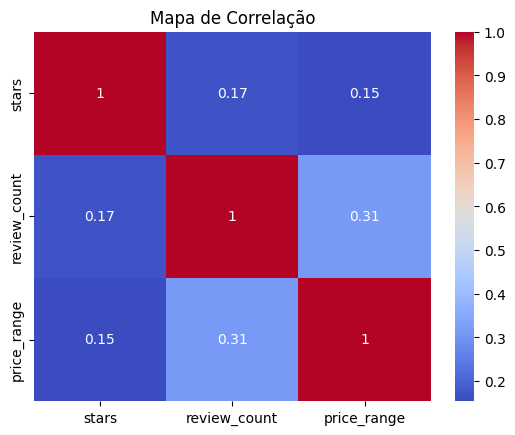

In [ ]:
# Correlação entre variáveis numéricas
plt.figure()
sns.heatmap(
    df[['stars', 'review_count', 'price_range']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Mapa de Correlação")
plt.show()

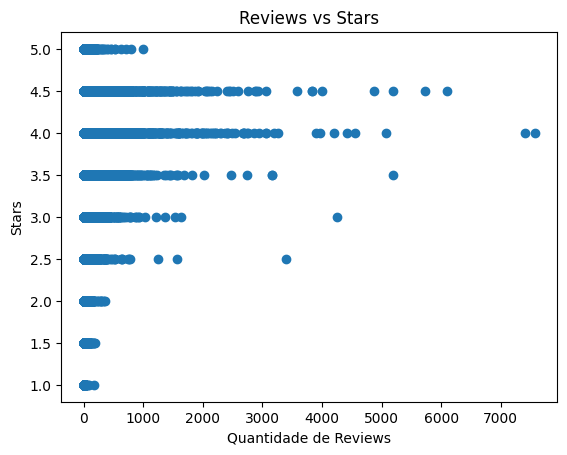

In [ ]:
# Relação entre reviews e estrelas
plt.figure()
plt.scatter(df['review_count'], df['stars'])
plt.title("Reviews vs Stars")
plt.xlabel("Quantidade de Reviews")
plt.ylabel("Stars")
plt.show()

# 3. Feature Engineering

In [ ]:
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer
from collections import Counter

#  Criando variável alvo (TARGET)
df['is_recommended'] = (df['stars'] >= 3.5).astype(int)

print(df['is_recommended'].value_counts(normalize=True))

is_recommended
1    0.677995
0    0.322005
Name: proportion, dtype: float64


In [ ]:
# Features base
features_base = [
    'review_count',
    'price_range',
    'has_delivery',
    'has_outdoor'
]

# remover nulos
df = df.dropna(subset=features_base)

# converter booleano para numérico
df['has_delivery'] = df['has_delivery'].astype(int)
df['has_outdoor'] = df['has_outdoor'].astype(int)

In [ ]:
# Processamento das categorias

all_categories = [cat for sublist in df['categories_list'] for cat in sublist]
freq = Counter(all_categories)

TOP_N = 30
top_categories = set([cat for cat, _ in freq.most_common(TOP_N)])

df['categories_filtered'] = df['categories_list'].apply(
    lambda cats: [c for c in cats if c in top_categories]
)

mlb = MultiLabelBinarizer()
categories_encoded = mlb.fit_transform(df['categories_filtered'])

df_categories = pd.DataFrame(
    categories_encoded,
    columns=mlb.classes_,
    index=df.index
)

print("Categorias usadas:", len(mlb.classes_))

Categorias usadas: 30


In [ ]:
# Dataset final
X = pd.concat([df[features_base], df_categories], axis=1)
y = df['is_recommended']

# 4. Treinamento dos Modelos

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Treino:", len(X_train), "| Teste:", len(X_test))

Treino: 27989 | Teste: 6998


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

modelos = {
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, class_weight='balanced'),
    "Neural Network": MLPClassifier(max_iter=400),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced')
}

resultados = {}
predicoes = {}

In [ ]:
# Treinar todos os modelos
for nome, model in modelos.items():
    print(f"\nTreinando {nome}...")
    
    model.fit(X_train, y_train)
    
    if nome == "Logistic Regression":
        prob = model.predict_proba(X_test)[:, 1]
        pred = (prob > 0.35).astype(int)
    else:
        pred = model.predict(X_test)
    
    predicoes[nome] = pred


Treinando Naive Bayes...

Treinando Decision Tree...

Treinando Neural Network...

Treinando Logistic Regression...


# 5. Avaliação + Gráficos

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

metricas = []

for nome, pred in predicoes.items():
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    
    metricas.append([nome, acc, prec, rec, f1])
    
    print("\n" + "="*50)
    print(nome)
    print("Acurácia:", acc)
    print("Precisão:", prec)
    print("Recall:", rec)
    print("F1:", f1)


Naive Bayes
Acurácia: 0.6839096884824235
Precisão: 0.7000633111744223
Recall: 0.9331223628691984
F1: 0.799963827093507

Decision Tree
Acurácia: 0.6288939697056302
Precisão: 0.8293882569935445
Recall: 0.5691983122362869
F1: 0.6750907043663206

Neural Network
Acurácia: 0.707344955701629
Precisão: 0.7206557377049181
Recall: 0.9274261603375528
F1: 0.811070110701107

Logistic Regression
Acurácia: 0.7084881394684196
Precisão: 0.7405559515324305
Recall: 0.8767932489451477
F1: 0.8029366306027821


# Comparação dos modelos

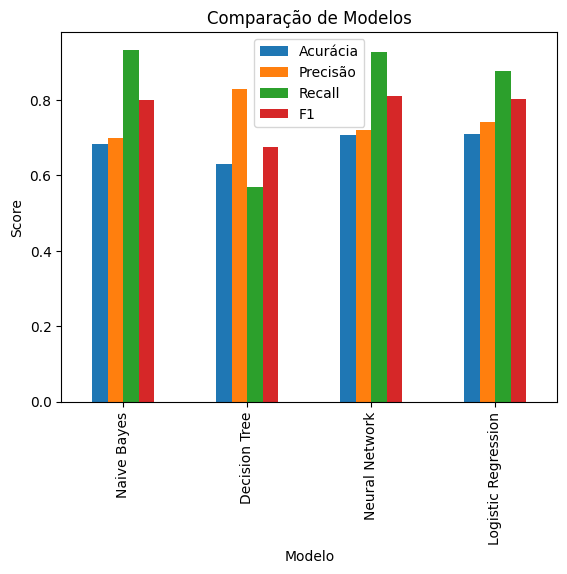

In [ ]:
df_metricas = pd.DataFrame(metricas, columns=[
    "Modelo", "Acurácia", "Precisão", "Recall", "F1"
])

df_metricas.set_index("Modelo").plot(kind='bar')
plt.title("Comparação de Modelos")
plt.ylabel("Score")
plt.show()

# Matriz de confusão

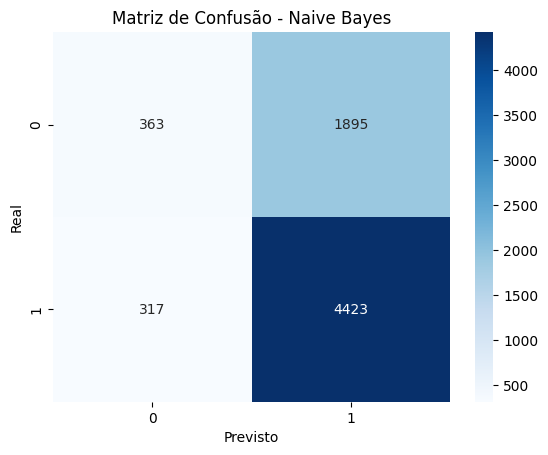

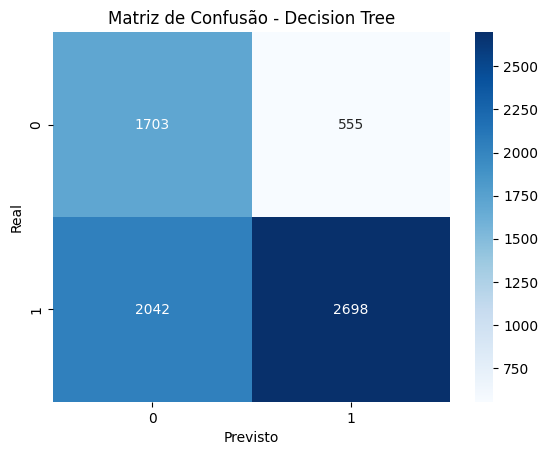

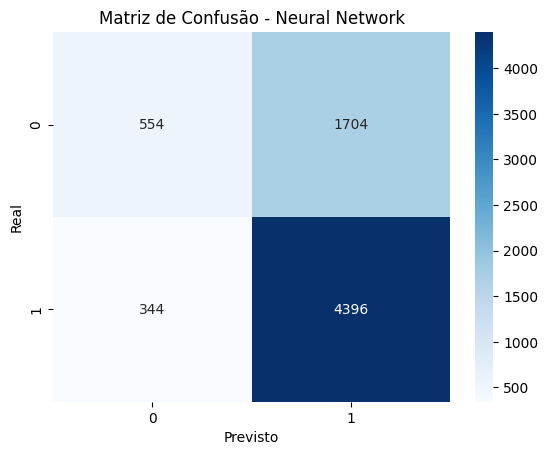

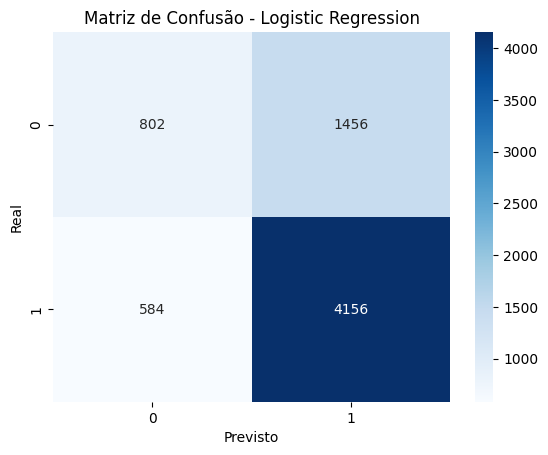

In [ ]:
for nome, pred in predicoes.items():
    plt.figure()
    matriz = confusion_matrix(y_test, pred)
    
    sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Matriz de Confusão - {nome}")
    plt.xlabel("Previsto")
    plt.ylabel("Real")
    plt.show()

# Ranking final dos modelos

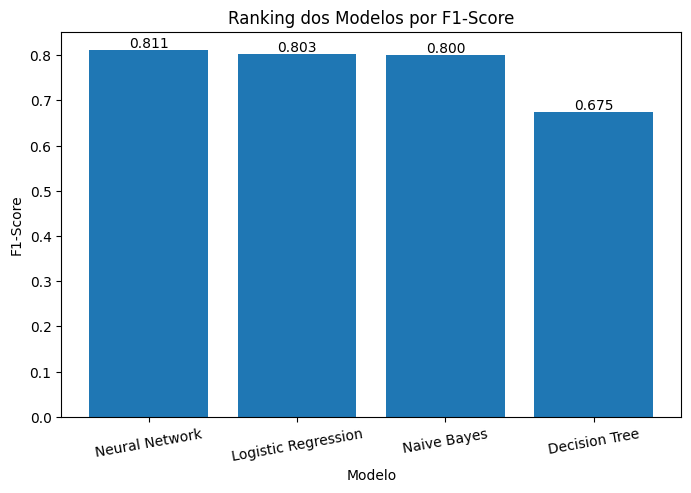

In [ ]:
# DataFrame apenas com F1-Score
df_f1 = pd.DataFrame(metricas, columns=[
    "Modelo", "Acurácia", "Precisão", "Recall", "F1"
])

# Mantém apenas Modelo e F1
df_f1 = df_f1[["Modelo", "F1"]]

# Ordena do maior para o menor
df_f1 = df_f1.sort_values(
    by="F1",
    ascending=False
)

# Criação manual do gráfico
fig, ax = plt.subplots(figsize=(8,5))

bars = ax.bar(
    df_f1["Modelo"],
    df_f1["F1"]
)

# Títulos
ax.set_title("Ranking dos Modelos por F1-Score")
ax.set_ylabel("F1-Score")
ax.set_xlabel("Modelo")

plt.xticks(rotation=10)

# Adiciona rótulos
for bar in bars:
    altura = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        altura + 0.005,
        f"{altura:.3f}",
        ha='center'
    )

plt.show()